# 03 — Modelo A: RGB (3 canais)

Baseline do estudo: treinamos a CNN usando **apenas as bandas visíveis** (B4, B3, B2 — vermelho, verde, azul). É o que uma câmera comum enxergaria.

Os modelos B e C usarão a **mesma arquitetura, seed, normalização e schedule** — mudando só o número de canais de entrada. Assim, qualquer diferença de acurácia é atribuível às bandas extras.

**Expectativa:** acurácia > 85%. Se ficar bem abaixo, algo está errado no pipeline.

In [1]:
import sys, os, json
sys.path.append(os.path.abspath('..'))

import numpy as np
import tensorflow as tf
from tensorflow.keras import mixed_precision
import matplotlib.pyplot as plt

from src import config, data_loader as dl, models, training, evaluation
from src import visualization as viz

# Ambiente: memory growth + mixed precision + seeds (idêntico nos 3 notebooks de treino).
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)
mixed_precision.set_global_policy('mixed_float16')
tf.random.set_seed(config.SEED); np.random.seed(config.SEED)
config.ensure_dirs()

MODEL_NAME = 'model_a_rgb'
CHANNELS = config.RGB_INDICES
print('Canais:', [config.BAND_NAMES[i] for i in CHANNELS])

I0000 00:00:1780157496.244517    1105 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Canais: ['B4', 'B3', 'B2']


## 1. Dados

Carregamos os splits e a normalização salva pelo notebook 02. O pipeline de treino usa augmentation; val e test, não.

In [2]:
train_ds, val_ds, test_ds = dl.make_splits()
mean, std = dl.load_norm_stats()

train_pipe = dl.build_pipeline(train_ds, CHANNELS, mean, std, augment=True, shuffle=True)
val_pipe = dl.build_pipeline(val_ds, CHANNELS, mean, std, augment=False, shuffle=False)
test_pipe = dl.build_pipeline(test_ds, CHANNELS, mean, std, augment=False, shuffle=False)

I0000 00:00:1780157512.371169    1105 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9709 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:06:00.0, compute capability: 8.6


## 2. Modelo

`build_cnn` com `input_shape=(64, 64, 3)`.

In [3]:
model = models.build_cnn(input_shape=(config.IMAGE_SIZE, config.IMAGE_SIZE, len(CHANNELS)))
training.compile_model(model)
model.summary()

Model: "eurosat_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             

 Total params: 289,642 (1.10 MB)

 Trainable params: 288,746 (1.10 MB)

 Non-trainable params: 896 (3.50 KB)

## 3. Treino

Callbacks: checkpoint do melhor (val_accuracy), early stopping (paciência 10, restaura melhores pesos), ReduceLROnPlateau e TensorBoard.

In [4]:
history, train_time = training.train_model(model, train_pipe, val_pipe, MODEL_NAME)
print(f'\nTempo de treino: {train_time:.0f}s')

Epoch 1/50


I0000 00:00:1780157517.263798    1800 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
I0000 00:00:1780157521.336070    1699 service.cc:153] XLA service 0x72ae9c03d4a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780157521.336226    1699 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.0)
I0000 00:00:1780157521.555044    1699 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780157522.052123    1699 cuda_dnn.cc:461] Loaded cuDNN version 92300
I0000 00:00:1780157522.148671    1699 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5575__.99


  1/296 ━━━━━━━━━━━━━━━━━━━━ 2:08:34 26s/step - accuracy: 0.0781 - loss: 2.8960

I0000 00:00:1780157541.096186    1699 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


294/296 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6000 - loss: 1.1455

I0000 00:00:1780157550.416971    1698 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5575__.99


296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.6005 - loss: 1.1439
Epoch 1: val_accuracy improved from None to 0.43580, saving model to results/models/model_a_rgb.keras

Epoch 1: finished saving model to results/models/model_a_rgb.keras
296/296 ━━━━━━━━━━━━━━━━━━━━ 58s 107ms/step - accuracy: 0.6802 - loss: 0.9079 - val_accuracy: 0.4358 - val_loss: 1.9421 - learning_rate: 0.0010
Epoch 2/50
292/296 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7929 - loss: 0.6165
Epoch 2: val_accuracy improved from 0.43580 to 0.81160, saving model to results/models/model_a_rgb.keras

Epoch 2: finished saving model to results/models/model_a_rgb.keras
296/296 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8037 - loss: 0.5812 - val_accuracy: 0.8116 - val_loss: 0.5224 - learning_rate: 0.0010
Epoch 3/50
294/296 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8312 - loss: 0.4992
Epoch 3: val_accuracy did not improve from 0.81160
296/296 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8437 - loss: 0

## 4. Avaliação no conjunto de teste

Reportamos **sempre no test set** (nunca no val). Mostramos acurácia, F1 macro, relatório por classe e matriz de confusão.

In [5]:
metrics = evaluation.evaluate_on_test(model, test_pipe)
print(f"Acurácia (teste): {metrics['accuracy']:.4f}")
print(f"F1 macro (teste): {metrics['f1_macro']:.4f}")
print()
print(evaluation.get_classification_report(metrics['y_true'], metrics['y_pred']))

Acurácia (teste): 0.9820
F1 macro (teste): 0.9813

                      precision    recall  f1-score   support

          AnnualCrop     0.9764    0.9672    0.9718       427
              Forest     0.9956    0.9956    0.9956       458
HerbaceousVegetation     0.9726    0.9638    0.9682       442
             Highway     0.9949    0.9898    0.9923       392
          Industrial     0.9779    0.9925    0.9852       402
             Pasture     0.9630    0.9896    0.9761       289
       PermanentCrop     0.9634    0.9580    0.9607       357
         Residential     1.0000    0.9867    0.9933       452
               River     0.9860    0.9751    0.9806       362
             SeaLake     0.9811    0.9979    0.9894       469

            accuracy                         0.9820      4050
           macro avg     0.9811    0.9816    0.9813      4050
        weighted avg     0.9820    0.9820    0.9820      4050



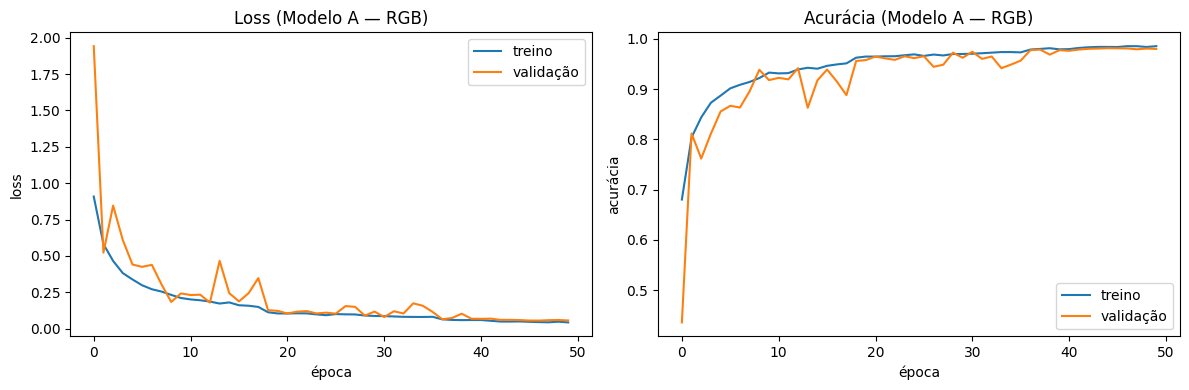

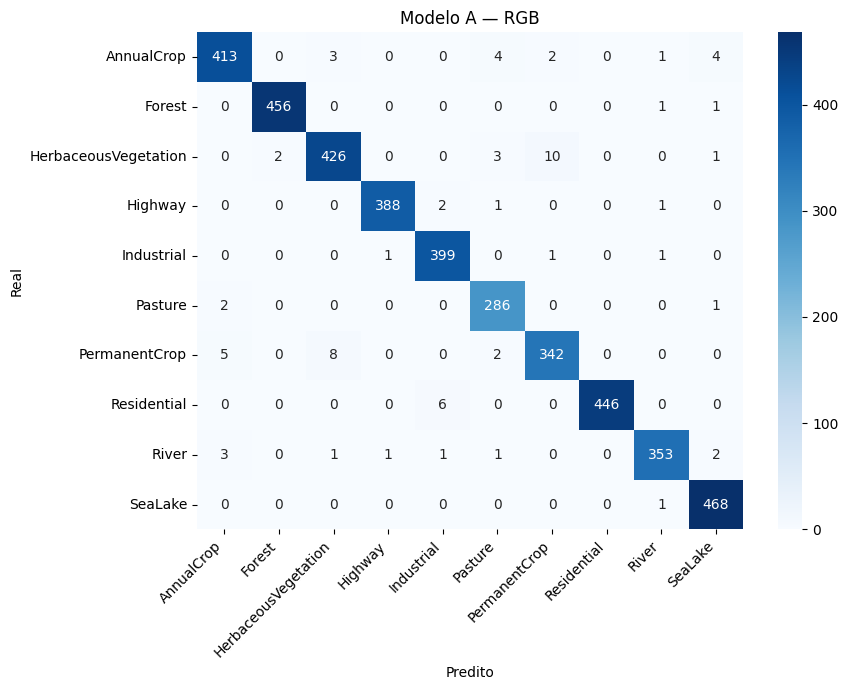

In [11]:
viz.plot_learning_curves(history, save_path=config.FIGURES_DIR / f'{MODEL_NAME}_curves.png', title_suffix='(Modelo A — RGB)')
plt.show()

cm, _ = evaluation.compute_confusion_matrix(metrics['y_true'], metrics['y_pred'])
viz.plot_confusion_matrix(cm, save_path=config.FIGURES_DIR / f'{MODEL_NAME}_confusion.png', title='Modelo A — RGB')
plt.show()

## 5. Salvar resultados

O melhor modelo já foi salvo pelo `ModelCheckpoint`. Salvamos o histórico e as métricas (com tempo de treino e nº de parâmetros) para o notebook de apresentação.

In [7]:
metrics['train_time_s'] = float(train_time)
metrics['num_params'] = int(model.count_params())
metrics['channels'] = [config.BAND_NAMES[i] for i in CHANNELS]
evaluation.save_metrics(metrics, config.METRICS_DIR / f'{MODEL_NAME}.json')

with open(config.HISTORIES_DIR / f'{MODEL_NAME}.json', 'w') as f:
    json.dump(history.history, f, indent=2)

print('Salvos:')
print(' -', config.MODELS_DIR / f'{MODEL_NAME}.keras')
print(' -', config.HISTORIES_DIR / f'{MODEL_NAME}.json')
print(' -', config.METRICS_DIR / f'{MODEL_NAME}.json')

Salvos:
 - results/models/model_a_rgb.keras
 - results/histories/model_a_rgb.json
 - results/metrics/model_a_rgb.json


**Próximo passo:** `04_train_model_b_rgb_nir.ipynb` — adiciona a banda NIR (B8).